In [1]:
# 6 strategies, used StraightForceToColony to see if results are different

# adding ApplyColonyPullingForce() to informed as 5 but more runs
# run on maze more time than 7 200 ants detchafter 4f to 10f 	float colonyPullStrength = 4.0f

#changes strategies 0  is always on 
#checking wich combination is the best
# Map 4 
# x3 amount of pheromones   public float dstBetweenMarkers = 0.75f; - > 0.2f

In [1]:
from sim_tools import run_simulation, SimulationParameters
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [3]:
num_sim = 5
steering_strategies = 6

use_pher = [i for i in range(steering_strategies*num_sim)]

batch_results2 = [(run_simulation(SimulationParameters(usePheromoneSteering=pher % steering_strategies), headless=True), pher % steering_strategies)
                 for pher in tqdm(use_pher)]

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [23:12<00:00, 46.42s/it]


In [4]:
Steering_names = [
    "home",
    "circle",
    "gradient",
    "gaussian",
    "Inverse Square",
    "Exponential",
]

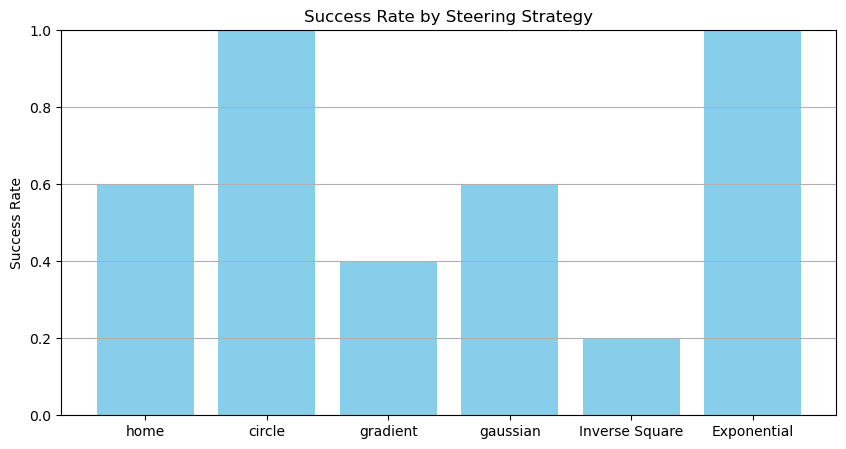

home: Success Rate=60.00% (3/5)
circle: Success Rate=100.00% (5/5)
gradient: Success Rate=40.00% (2/5)
gaussian: Success Rate=60.00% (3/5)
Inverse Square: Success Rate=20.00% (1/5)
Exponential: Success Rate=100.00% (5/5)


In [5]:
def plot_success_rates(batch_results, num_strategies=6, strategy_names=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for res, strategy in batch_results:
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and getattr(res, "didSucceed", False):
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), success_rates,
            tick_label=labels, color='skyblue')
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


plot_success_rates(batch_results2, steering_strategies, Steering_names)

In [6]:
# print results
def print_results(batch_results):
    for res, ss in batch_results:
        if res:
            print(
                f"Run (usePheromoneSteering={ss}): Success, duration={res.duration}, success={res.didSucceed}")
        else:
            print(f"Run (usePheromoneSteering={ss}): Failed")                      

In [7]:
print_results(batch_results2)

Run (usePheromoneSteering=0): Success, duration=283.4815979003906, success=True
Run (usePheromoneSteering=1): Success, duration=230.53448486328125, success=True
Run (usePheromoneSteering=2): Success, duration=5000.02294921875, success=False
Run (usePheromoneSteering=3): Success, duration=336.2251281738281, success=True
Run (usePheromoneSteering=4): Success, duration=5000.109375, success=False
Run (usePheromoneSteering=5): Success, duration=353.83984375, success=True
Run (usePheromoneSteering=0): Success, duration=5000.02490234375, success=False
Run (usePheromoneSteering=1): Success, duration=190.4219970703125, success=True
Run (usePheromoneSteering=2): Success, duration=2182.920654296875, success=True
Run (usePheromoneSteering=3): Success, duration=5000.05126953125, success=False
Run (usePheromoneSteering=4): Success, duration=5000.12841796875, success=False
Run (usePheromoneSteering=5): Success, duration=412.9910583496094, success=True
Run (usePheromoneSteering=0): Success, duration=1

In [8]:
import matplotlib.pyplot as plt


def plot_torus_positions_by_strategy(batch_results, strategy_names=None):
    """
    Plots the torus positions for each strategy in separate graphs.
    Each plot shows the paths for all successful runs of that strategy.
    """
    num_strategies = max(pher for _, pher in batch_results) + 1
    if strategy_names is None:
        strategy_names = [f"Steering={i}" for i in range(num_strategies)]

    for strategy in range(num_strategies):
        # Collect all successful torus positions for this strategy
        paths = [
            res.torusPositions for res, pher in batch_results
            if pher == strategy and res and hasattr(res, "torusPositions") and res.didSucceed
        ]
        if not paths:
            continue  # Skip if no successful runs

        plt.figure(figsize=(6, 6))
        for path in paths:
            xs = [p.x for p in path]
            ys = [p.y for p in path]
            plt.plot(xs, ys, alpha=0.5)
        plt.title(f"Torus Paths - {strategy_names[strategy]}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

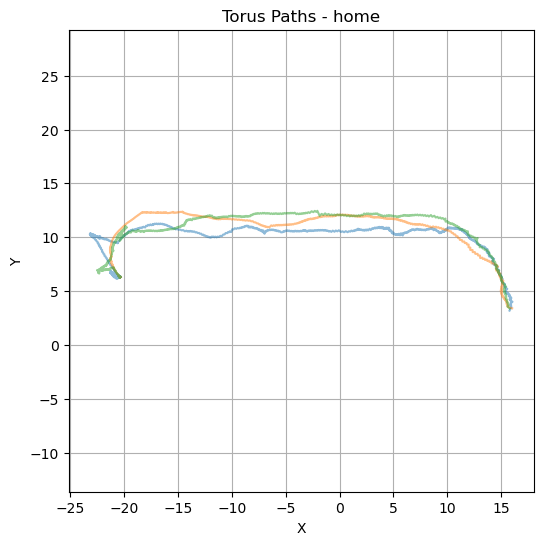

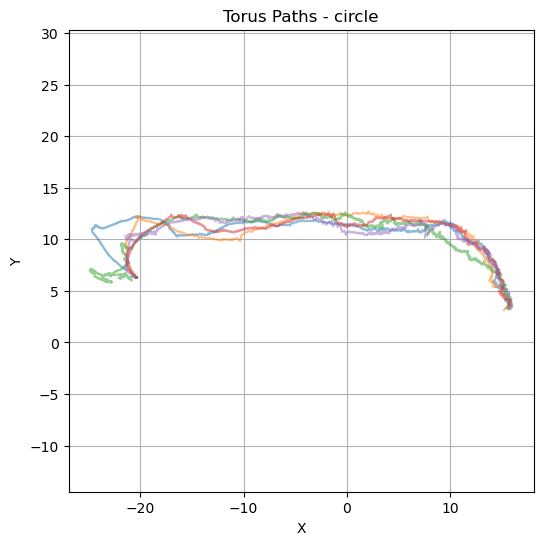

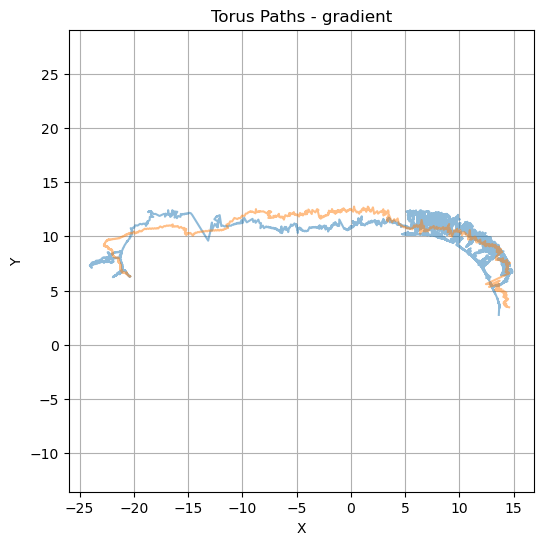

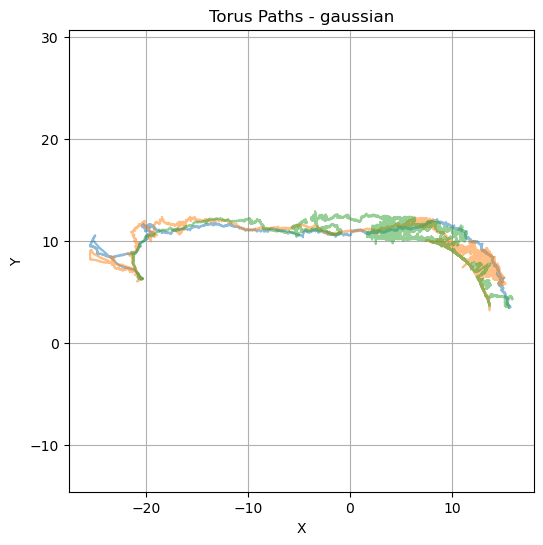

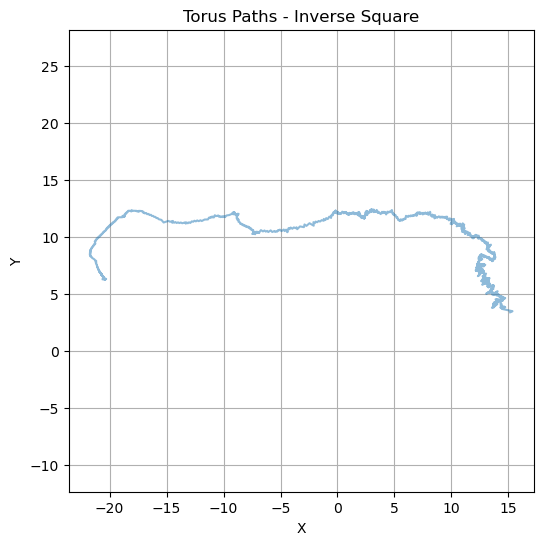

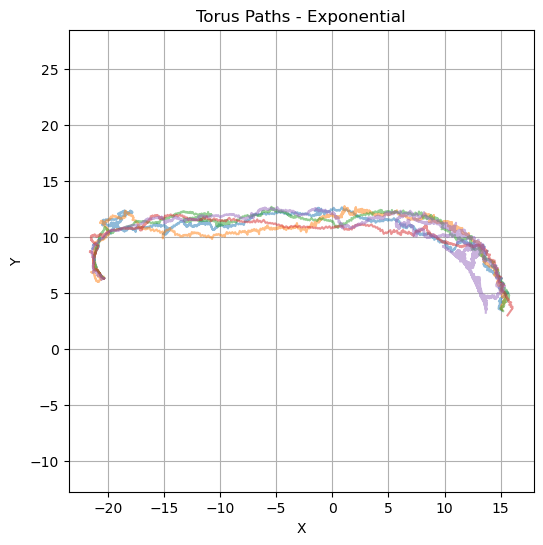

In [9]:
plot_torus_positions_by_strategy(batch_results2, Steering_names)

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def plot_duration_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """
    # Determine number of strategies
    num_strategies = max(pher for _, pher in batch_results) + 1

    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False):
            durations_by_strategy[strategy].append(res.duration)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(durations_by_strategy, tick_labels=labels)
    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average duration for each strategy
    for i in range(num_strategies):
        avg = np.mean(
            durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")

# Example usage:

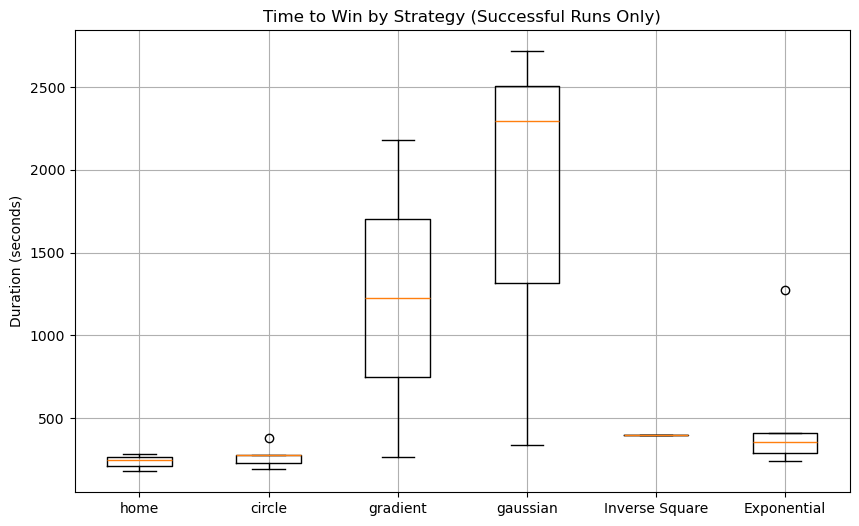

home: Average Duration = 236.62 seconds
circle: Average Duration = 271.01 seconds
gradient: Average Duration = 1224.90 seconds
gaussian: Average Duration = 1781.60 seconds
Inverse Square: Average Duration = 395.66 seconds
Exponential: Average Duration = 514.81 seconds


In [11]:
plot_duration_comparison(batch_results2, Steering_names)

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def compute_path_length(points):
    """Compute total path length from a list of Point objects with x, y attributes."""
    if not points or len(points) < 2:
        return 0
    return sum(
        np.linalg.norm([points[i+1].x - points[i].x,
                       points[i+1].y - points[i].y])
        for i in range(len(points)-1)
    )


def plot_path_length_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the total path length for each strategy.
    Only successful runs are included.
    """
    # Determine number of strategies
    num_strategies = max(pher for _, pher in batch_results) + 1

    # Collect path lengths for each strategy
    path_lengths_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            path_length = compute_path_length(res.torusPositions)
            path_lengths_by_strategy[strategy].append(path_length)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(path_lengths_by_strategy, tick_labels=labels)
    plt.ylabel("Total Path Length")
    plt.title("Torus Path Length by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average path length for each strategy
    for i in range(num_strategies):
        avg = np.mean(
            path_lengths_by_strategy[i]) if path_lengths_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Path Length = {avg:.2f}")

# Example usage:

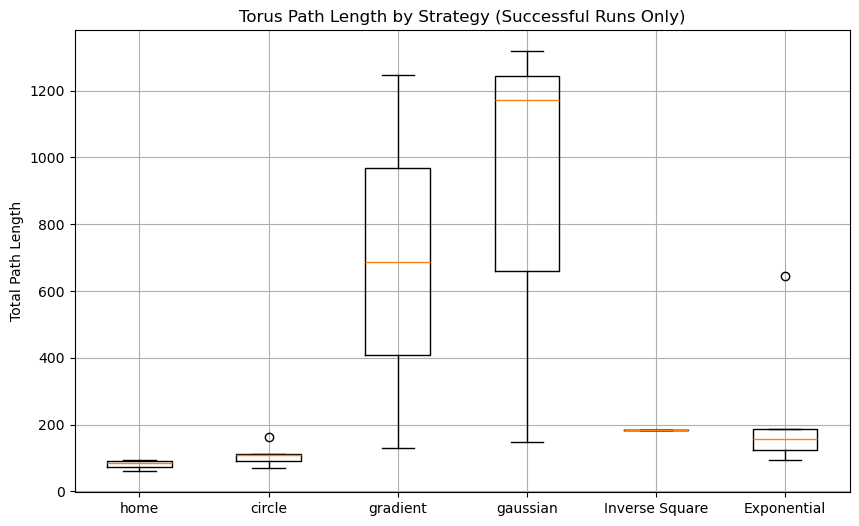

home: Average Path Length = 79.75
circle: Average Path Length = 108.73
gradient: Average Path Length = 687.78
gaussian: Average Path Length = 878.55
Inverse Square: Average Path Length = 184.02
Exponential: Average Path Length = 241.36


In [13]:
plot_path_length_comparison(batch_results2, Steering_names)

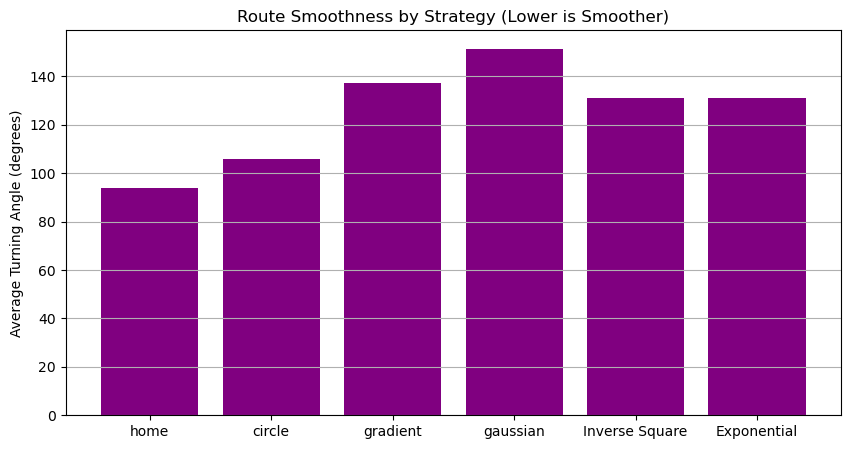

home: Average Turning Angle = 93.75°
circle: Average Turning Angle = 105.78°
gradient: Average Turning Angle = 137.08°
gaussian: Average Turning Angle = 151.47°
Inverse Square: Average Turning Angle = 131.13°
Exponential: Average Turning Angle = 131.05°


In [14]:
import numpy as np
import matplotlib.pyplot as plt


def compute_average_turning_angle(points):
    """Compute the average turning angle (in degrees) for a path of Point objects."""
    if not points or len(points) < 3:
        return 0
    angles = []
    for i in range(1, len(points)-1):
        v1 = np.array([points[i].x - points[i-1].x,
                      points[i].y - points[i-1].y])
        v2 = np.array([points[i+1].x - points[i].x,
                      points[i+1].y - points[i].y])
        if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
            continue
        cos_angle = np.clip(
            np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1)
        angle = np.arccos(cos_angle)
        angles.append(np.degrees(angle))
    return np.mean(angles) if angles else 0


def plot_smoothness_comparison(batch_results, strategy_names=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    num_strategies = max(pher for _, pher in batch_results) + 1
    smoothness_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[strategy].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float(
            'nan')
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), mean_smoothness,
            tick_label=labels, color='purple')
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")

# Example usage:
plot_smoothness_comparison(batch_results2, Steering_names)